In [4]:
import numpy as np #handling array objects
import os #doing the file seeking to find the right location in the file
import matplotlib.pyplot as plt #plotting
from scipy.optimize import curve_fit
import tqdm
import scipy

In [30]:
def readInOutputFile(outputFilename, padding=1):
    optionsStructType = np.dtype([
        ('B0', np.float64, 3),
        ('E', np.float64, 3),
        ('L', np.float64, 3),
        ('yi', np.float64, 3),
        ('m', np.float64),
        ('t0', np.float64),
        ('tf', np.float64),
        ('rtol', np.float64),
        ('atol', np.float64),
        ('beta', np.float64),
        ('uround', np.float64),
        ('safe', np.float64),
        ('fac1', np.float64),
        ('fac2', np.float64),
        ('hmax', np.float64),
        ('hmin', np.float64),
        ('h', np.float64),
        ('T', np.float64),
        ('sqrtKT_m', np.float64),
        ('tc', np.float64),
        ('gamma', np.float64),
        ('V', np.float64),
        ('a', np.float64),
        ('w', np.float64),
        ('swapStepSize', np.float64),
        ('maxPosStep', np.float64),
        ('ioutInt', np.float64),
        ('diffuse', np.float64),
        ('nmax', np.uint32),
        ('seed', np.uint32),
        ('integratorType', np.int32),
        ('numParticles', np.int32),
        ('numPerGPUBlock', np.int32),
        ('iout', np.int32),
        ('dist', 'S', 1),
        ('gas_coll', bool),
        ('gravity', bool),
        ('fixedStepSize', bool),
        ('keepStepSize', bool),
        ('noiseEnable', bool),
        ('noiseAmplitudes', np.float64, 3),
        ('noiseFrequencies', np.float64, 3),
        ('pad', 'S', padding) #this is padding space just designed to fix the structure padding done in C++
    ])
    file = open(outputFilename, 'rb')
    parameters = np.fromfile(file, count=1, dtype=optionsStructType)[0]
    data = None
    #in this case it was the full dump of all particle data
    npart = parameters['numParticles']
    coordDtype = np.dtype([
        ('x', '<f8'),
        ('y', '<f8'),
        ('z', '<f8')])
    outputDtype = np.dtype([
        ('t', '<f8', npart),
        ('x', coordDtype, npart),
        ('v', coordDtype, npart),
        ('s', coordDtype, npart),
        ('failureState', 'i4', npart),
        ('n_coll', 'u8', npart),
        ('n_bounce', 'u8', npart),
        ('n_step', 'u8', npart)])
    file.seek(0, 0)
    data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
    numTimes = data.shape[0]//parameters['numParticles']
    numPer = int((parameters['tf']-parameters['t0'])/parameters['ioutInt'])+1
    #data = data[:numTimes*parameters['numParticles']].reshape(-1, parameters['numParticles']).T #this returns the data in a little more convenient format, I think

    if parameters['integratorType'] == 6:
        print(parameters.nbytes + data.nbytes)
        b_end = np.fromfile(file, dtype=np.dtype((np.float64, 3)))[0]#, offset=parameters.nbytes + data.nbytes)
    else:
        b_end = None
    file.close()
    return parameters, data, b_end

def shiftDatapoints(phis):
    shifted = np.copy(phis)
    initHist, bins = np.histogram(phis, bins = 1000) #calculate the initial histogram and then adjust based on the mode
    peakloc = np.argmax(initHist)
    location = bins[peakloc]
    #shift everything to be close to that peak
    lowLocs = shifted<=(location-np.pi)
    highLocs = shifted>=(location+np.pi)
    shifted[lowLocs] += 2.0*np.pi
    shifted[highLocs] -= 2.0*np.pi
    mean = np.nanmean(shifted)
    std = np.nanstd(shifted)
    shifted[shifted<(mean-std*5)] = np.nan
    shifted[shifted>(mean+std*5)] = np.nan
    return shifted

def analyzeDataset(dset, randomSample = False, plot=False, coord1 = 'sy', coord2 = 'sz'):
    times = np.sort(np.unique(dset[0]['t']))
    phis = np.arctan2(dset[coord1], dset[coord2])
    for i in range(len(times)):
        if randomSample:
            phis[:,i] = shiftDatapoints(np.random.choice(phis[:,i], size=phis[:,i].shape))
        else:
            phis[:,i] = shiftDatapoints(phis[:,i])
        if plot:
            plt.hist(phis[:,i], bins = 1000)
            plt.title(times[i])
            plt.yscale('log')
            plt.show()
    means = np.nanmean(phis, axis=0)
    stds = np.nanstd(phis, axis=0)
    means = np.abs(means)
    return times, means, stds

def writeParameterFile(filename, runParameters):
    with open(filename, 'w') as f:
        for key in runParameters:
            if key == 'particle':
                if runParameters['particle'] == 'neutron':
                    gamma = '-1.832471850e8'
                    m = '1.674927e-27'
                    f.write('gamma, '+gamma + '\n')
                    f.write('m, '+m + '\n')
                elif runParameters['particle'] == 'helium-3':
                    gamma = '-2.037947093e8'
                    m = '1.20200437865e-26'
                    f.write('gamma, '+gamma + '\n')
                    f.write('m, '+m)
            else:
                f.write(key + ', '+runParameters[key]+'\n')
    return

In [32]:
dop_data = readInOutputFile('/storage/home/hcodaman1/rtat3/scratch/floquet_out.dat',padding=2)
parameters, data, b_end = dop_data
b_end

36656


array([nan, nan, nan])

In [34]:
newDOP = readInOutputFile('/storage/home/hcoda1/9/dmathews33/scratch/trash/newDOP.out')
newRK45Quat = readInOutputFile('/storage/home/hcoda1/9/dmathews33/scratch/trash/newRK45Quat.out')
newMagnus = readInOutputFile('/storage/home/hcoda1/9/dmathews33/scratch/trash/newMagnus.out')
newRK45 = readInOutputFile('/storage/home/hcoda1/9/dmathews33/scratch/trash/newRK45.out')

In [3]:
new = readInOutputFile('/storage/home/hcoda1/9/dmathews33/scratch/trash/0.out')
old = readInOutputFile('/storage/home/hcoda1/9/dmathews33/scratch/trash/.out')


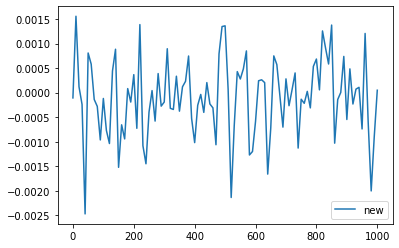

In [18]:
coord = 'xz'
plt.plot(new[1]['t'][0], new[1][coord][:].mean(axis=0) - old[1][coord][:].mean(axis=0), label='new')
plt.legend()
#plt.xlim(0, 0.1)
plt.show()

In [10]:
new[1][coord][:].mean(axis=0)

array([ 1.        ,  0.93176114,  0.73636162,  0.44046783,  0.08446223,
       -0.28306892, -0.61196754, -0.85734787, -0.98572183, -0.97957024,
       -0.8397329 , -0.58529387, -0.25097829,  0.11758787,  0.47010584,
        0.75846691,  0.94331653,  0.99942723,  0.91914159,  0.71341694,
        0.41033075,  0.05124594, -0.31483215, -0.63794392, -0.87399297,
       -0.99076389, -0.9723211 , -0.82118134, -0.55797281, -0.21861586,
        0.15057545,  0.49921601,  0.77972588,  0.95382374,  0.99775049,
        0.90551108,  0.68969342,  0.379751  ,  0.01798319, -0.34623864,
       -0.66320737, -0.88966587, -0.99470751, -0.96399695, -0.80172739,
       -0.53004376, -0.18602353,  0.18338333,  0.52776281,  0.80011589,
        0.96327358,  0.99496895,  0.89087669,  0.66520364,  0.34874801,
       -0.01530267, -0.37726385, -0.68773696, -0.9043514 , -0.99754606,
       -0.95460182, -0.78137858, -0.50151731, -0.1532116 ,  0.21600362,
        0.5557389 ,  0.81962902,  0.9716599 ,  0.99108443,  0.87

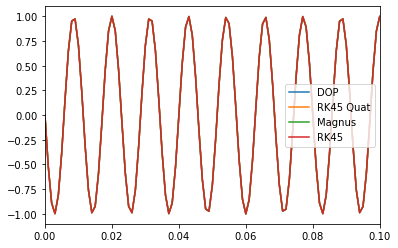

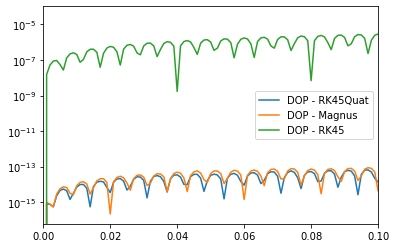

In [39]:
coord = 'sy'
plt.plot(newDOP[1]['t'][0], newDOP[1][coord][:].mean(axis=0), label='DOP')
plt.plot(newRK45Quat[1]['t'][0], newRK45Quat[1][coord][:].mean(axis=0), label='RK45 Quat')
plt.plot(newMagnus[1]['t'][0], newMagnus[1][coord][:].mean(axis=0), label='Magnus')
plt.plot(newRK45[1]['t'][0], newRK45[1][coord][:].mean(axis=0), label='RK45')
plt.legend()
plt.xlim(0, 0.1)
plt.show()

coord = 'sy'
plt.plot(newDOP[1]['t'][0], abs(newDOP[1][coord][:].mean(axis=0) - newRK45Quat[1][coord][:].mean(axis=0)), label='DOP - RK45Quat')
plt.plot(newDOP[1]['t'][0], abs(newDOP[1][coord][:].mean(axis=0) - newMagnus[1][coord][:].mean(axis=0)), label='DOP - Magnus')
plt.plot(newDOP[1]['t'][0], abs(newDOP[1][coord][:].mean(axis=0) - newRK45[1][coord][:].mean(axis=0)), label='DOP - RK45')
plt.yscale('log')
plt.legend()
plt.xlim(0, 0.1)
plt.show()

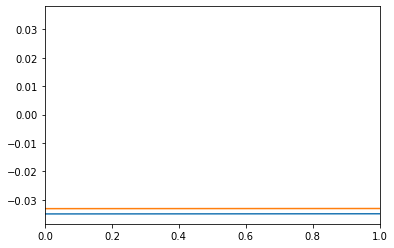

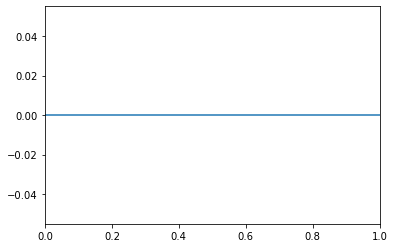

In [8]:
plt.plot(newFile[1][0]['t'], newFile[1][0]['xx'])
plt.plot(original[1][0]['t'], original[1][0]['xx'])
plt.xlim(0, 1.0)
plt.show()

plt.plot(newFile[1][0]['t'], newFile[1][0]['sy'] - original[1][0]['sy'])
plt.xlim(0, 1.0)
plt.show()

In [28]:
original[1]

In [26]:
stepSizes = ['1.0e-4', '1.0e-5', '1.0e-6', '1.0e-7', '1.0e-8']
names = ['4', '5', '6', '7', '8']

DOPResults = []
MagnusResults = []
RK45Results = []
RK45QuatResults = []
for name, step in zip(names, stepSizes):
    filename = 'neutronTest.txt'
    outDir = '/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/'
    parameters = {}
    parameters['particle'] = 'neutron'
    parameters['V']='0.0'
    parameters['T']='0.4'
    parameters['gas_coll']='false'
    parameters['diffuse']='false'
    parameters['gravity']='false'
    parameters['B0'] = '3.0e-6, 0, 0'
    parameters['E'] = '75.0e5, 0, 0'
    parameters['numParticles'] = '1'
    parameters['t0']='0.0'
    parameters['tf']='1.0'
    parameters['ioutInt']='0.001'
    parameters['a']= '0' #'19.1024180e-6'
    parameters['w']='0' #'3000.0'
    parameters['h']=step
    parameters['swapStepSize'] = '1.0e0'
    parameters['keepStepSize'] = 'false'
    parameters['fixedStepSize'] = 'true'
    parameters['dist'] = 'C'
    parameters['rtol'] = '1.0e-14'
    parameters['atol'] = '1.0e-14'
    parameters['hmax'] = '1.0'
    parameters['hmin'] = '1.0e-9'
    parameters['numPerGPUBlock'] = '256'
    parameters['output'] = 'n'
    parameters['seed'] = '0'

    parameters['integratorType']='0'
    writeParameterFile(filename, parameters)
    outname = outDir + 'DOP'+name+'.out'
    print(outname)
    !~/Spin-tracking/cpumain ~/Spin-tracking/scripts/neutronTest.txt {outname} > trash
    DOPResults.append(readInOutputFile(outname))
    
    parameters['swapStepSize'] = '1.0' #force it to use the traditional RK45 approach
    parameters['integratorType']='1'
    writeParameterFile(filename, parameters)
    outname = outDir + 'RK45'+name+'.out'
    print(outname)
    !~/Spin-tracking/cpumain ~/Spin-tracking/scripts/neutronTest.txt {outname} > trash
    RK45Results.append(readInOutputFile(outname))
    
    parameters['swapStepSize'] = '1.0e-9' #force it to use the quaternion approach
    parameters['integratorType']='1'
    writeParameterFile(filename, parameters)
    outname = outDir + 'RK45Quat'+name+'.out'
    print(outname)
    !~/Spin-tracking/cpumain ~/Spin-tracking/scripts/neutronTest.txt {outname} > trash
    RK45QuatResults.append(readInOutputFile(outname))

    parameters['integratorType']='2'
    writeParameterFile(filename, parameters)
    outname = outDir + 'Magnus'+name+'.out'
    print(outname)
    !~/Spin-tracking/cpumain ~/Spin-tracking/scripts/neutronTest.txt {outname} > trash
    MagnusResults.append(readInOutputFile(outname))

/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/DOP4.out
/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/RK454.out
/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/RK45Quat4.out
/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/Magnus4.out
/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/DOP5.out
/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/RK455.out
/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/RK45Quat5.out
/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/Magnus5.out
/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/DOP6.out
/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/RK456.out
/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/RK45Quat6.out
/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/Magnus6.out
/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initia

In [27]:
filename = 'neutronTest.txt'
outDir = '/storage/home/hcoda1/9/dmathews33/scratch/spinDressing/initialTest/'
parameters = {}
parameters['particle'] = 'neutron'
parameters['V']='0.0'
parameters['T']='0.4'
parameters['gas_coll']='false'
parameters['diffuse']='false'
parameters['gravity']='false'
parameters['B0'] = '3.0e-6, 0, 0'
parameters['E'] = '75.0e5, 0, 0'
parameters['numParticles'] = '1'
parameters['t0']='0.0'
parameters['tf']='1.0'
parameters['ioutInt']='0.001'
parameters['a']= '0.0' #'19.1024180e-6'
parameters['w']= '0.0' #'3000.0'
parameters['h']=step
parameters['swapStepSize'] = '1.0e0'
parameters['keepStepSize'] = 'false'
parameters['fixedStepSize'] = 'false'
parameters['dist'] = 'C'
parameters['rtol'] = '1.0e-14'
parameters['atol'] = '1.0e-14'
parameters['hmax'] = '1.0'
parameters['hmin'] = '1.0e-9'
parameters['numPerGPUBlock'] = '256'
parameters['output'] = 'n'
parameters['seed'] = '0'

parameters['integratorType']='0'
writeParameterFile(filename, parameters)
outname = outDir + 'adaptiveDOP.out'
!~/Spin-tracking/cpumain ~/Spin-tracking/scripts/neutronTest.txt {outname} > trash
DOPAdaptive = readInOutputFile(outname)

parameters['integratorType']='2'
writeParameterFile(filename, parameters)
outname = outDir + 'adaptiveMagnus.out'
!~/Spin-tracking/cpumain ~/Spin-tracking/scripts/neutronTest.txt {outname} > trash
MagnusAdaptive = readInOutputFile(outname)

In [47]:
coord = ['sx', 'sy', 'sz']
test = DOPResults[-1][1][coord][0,:]

In [49]:
test.dot(test)

TypeError: can't multiply sequence by non-int of type 'tuple'

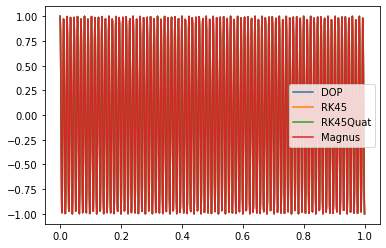

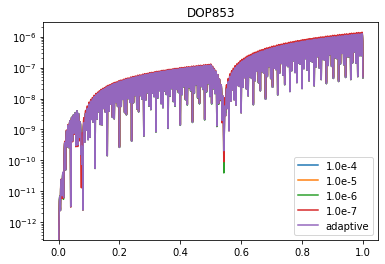

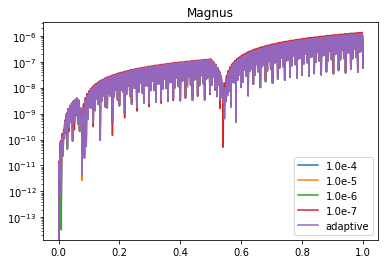

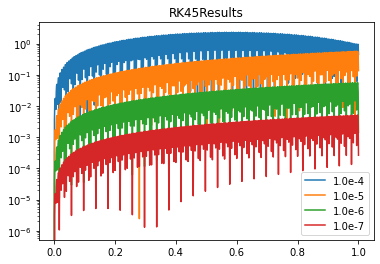

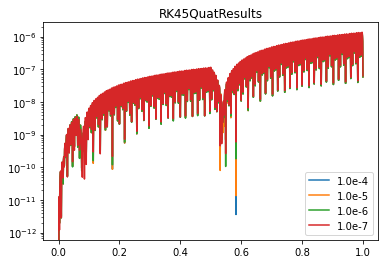

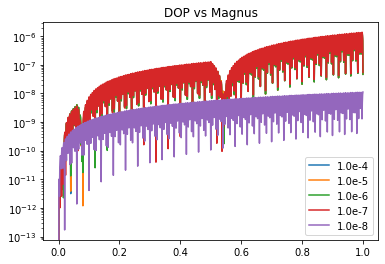

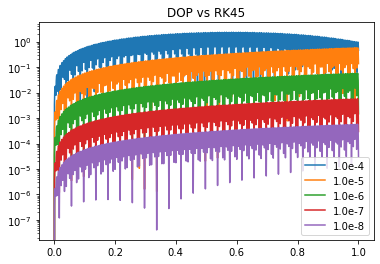

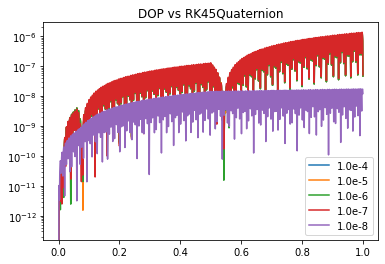

In [35]:
# Compare the adaptive and fixed step size approaches for DOP and Magnus
#plot the 'best' results

coord = 'sz'
plt.plot(DOPResults[-1][1]['t'][0,:], DOPResults[-1][1][coord][0,:], label='DOP')
plt.plot(RK45Results[-1][1]['t'][0,:], RK45Results[-1][1][coord][0,:], label='RK45')
plt.plot(RK45QuatResults[-1][1]['t'][0,:], RK45QuatResults[-1][1][coord][0,:], label='RK45Quat')
plt.plot(MagnusResults[-1][1]['t'][0,:], MagnusResults[-1][1][coord][0,:], label='Magnus')
plt.legend()
plt.show()



for i in range(len(DOPResults)-1):
    plt.plot(DOPResults[-1][1]['t'][0,:], abs(DOPResults[-1][1][coord][0,:] - DOPResults[i][1][coord][0,:]), label=stepSizes[i])
plt.plot(DOPResults[-1][1]['t'][0,:], abs(DOPResults[-1][1][coord][0,:] - DOPAdaptive[1][coord][0,:]), label='adaptive')
plt.title('DOP853')
plt.legend()
plt.yscale('log')
plt.show()

for i in range(len(MagnusResults)-1):
    plt.plot(MagnusResults[-1][1]['t'][0,:], abs(MagnusResults[-1][1][coord][0,:] - MagnusResults[i][1][coord][0,:]), label=stepSizes[i])
plt.plot(MagnusResults[-1][1]['t'][0,:], abs(MagnusResults[-1][1][coord][0,:] - MagnusAdaptive[1][coord][0,:]), label='adaptive')
plt.title('Magnus')
plt.legend()
plt.yscale('log')
plt.show()

for i in range(len(MagnusResults)-1):
    plt.plot(RK45Results[-1][1]['t'][0,:], abs(RK45Results[-1][1][coord][0,:] - RK45Results[i][1][coord][0,:]), label=stepSizes[i])
plt.title('RK45Results')
plt.legend()
plt.yscale('log')
plt.show()

for i in range(len(MagnusResults)-1):
    plt.plot(RK45QuatResults[-1][1]['t'][0,:], abs(RK45QuatResults[-1][1][coord][0,:] - RK45QuatResults[i][1][coord][0,:]), label=stepSizes[i])
plt.title('RK45QuatResults')
plt.legend()
plt.yscale('log')
plt.show()

for i in range(len(MagnusResults)):
    plt.plot(DOPResults[-1][1]['t'][0,:], abs(DOPResults[-1][1][coord][0,:] - MagnusResults[i][1][coord][0,:]), label=stepSizes[i])
plt.title('DOP vs Magnus')
plt.legend()
plt.yscale('log')
plt.show()

for i in range(len(MagnusResults)):
    plt.plot(DOPResults[-1][1]['t'][0,:], abs(DOPResults[-1][1][coord][0,:] - RK45Results[i][1][coord][0,:]), label=stepSizes[i])
plt.title('DOP vs RK45')
plt.legend()
plt.yscale('log')
plt.show()

for i in range(len(MagnusResults)):
    plt.plot(DOPResults[-1][1]['t'][0,:], abs(DOPResults[-1][1][coord][0,:] - RK45QuatResults[i][1][coord][0,:]), label=stepSizes[i])
plt.title('DOP vs RK45Quaternion')
plt.legend()
plt.yscale('log')
plt.show()

In [36]:
diffs = []
for dset in [MagnusResults, DOPResults, RK45Results, RK45QuatResults]:
    tempDiffs = []
    for dset2 in [MagnusResults, DOPResults, RK45Results, RK45QuatResults]:
        tempDiffs.append(np.mean(abs(dset[-1][1][coord][0,:] - dset2[-1][1][coord][0,:])))
    diffs.append(tempDiffs)
diffs = np.array(diffs)
print(diffs)

[[0.00000000e+00 3.58577409e-09 1.83321258e-04 6.04897309e-09]
 [3.58577409e-09 0.00000000e+00 1.83320996e-04 7.16281823e-09]
 [1.83321258e-04 1.83320996e-04 0.00000000e+00 1.83315241e-04]
 [6.04897309e-09 7.16281823e-09 1.83315241e-04 0.00000000e+00]]


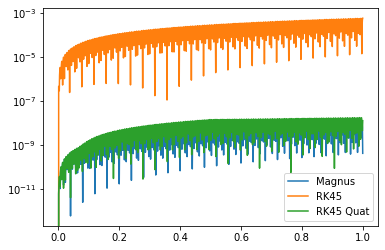

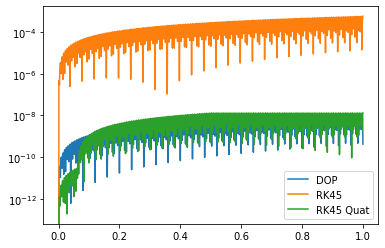

In [38]:
coord = 'sy'
plt.plot(MagnusResults[-1][1]['t'][0,:], abs(DOPResults[-1][1][coord][0,:] - MagnusResults[i][1][coord][0,:]), label='Magnus')
plt.plot(MagnusResults[-1][1]['t'][0,:], abs(DOPResults[-1][1][coord][0,:] - RK45Results[i][1][coord][0,:]), label='RK45')
plt.plot(MagnusResults[-1][1]['t'][0,:], abs(DOPResults[-1][1][coord][0,:] - RK45QuatResults[i][1][coord][0,:]), label='RK45 Quat')
plt.legend()
plt.yscale('log')
plt.show()

plt.plot(MagnusResults[-1][1]['t'][0,:], abs(MagnusResults[-1][1][coord][0,:] - DOPResults[i][1][coord][0,:]), label='DOP')
plt.plot(MagnusResults[-1][1]['t'][0,:], abs(MagnusResults[-1][1][coord][0,:] - RK45Results[i][1][coord][0,:]), label='RK45')
plt.plot(MagnusResults[-1][1]['t'][0,:], abs(MagnusResults[-1][1][coord][0,:] - RK45QuatResults[i][1][coord][0,:]), label='RK45 Quat')
plt.legend()
plt.yscale('log')
plt.show()

In [28]:
parameters['h']='1.0e-8'
parameters['swapStepSize'] = '1.0e0'
parameters['keepStepSize'] = 'false'
parameters['fixedStepSize'] = 'True'
parameters['integratorType']='1'
writeParameterFile(filename, parameters)
outname = outDir + 'initTestDOPCPU.out'
!~/Spin-tracking/gpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}
resultsRK45Regular8 = readInOutputFile(outname)

248
0, 0.001, 2819
1, 0.002, 2827
2, 0.003, 2794
3, 0.004, 2759
4, 0.005, 2786
5, 0.006, 2799
6, 0.007, 2804
7, 0.008, 2693
8, 0.009, 2824
9, 0.01, 2799
10, 0.011, 2819
11, 0.012, 2824
12, 0.013, 2838
13, 0.014, 2772
14, 0.015, 2812
15, 0.016, 2810
16, 0.017, 2793
17, 0.018, 2889
18, 0.019, 2810
19, 0.02, 2809
20, 0.021, 2733
21, 0.022, 2797
22, 0.023, 2794
23, 0.024, 2824
24, 0.025, 2816
25, 0.026, 2774
26, 0.027, 2784
27, 0.028, 2848
28, 0.029, 2810
29, 0.03, 2794
30, 0.031, 2670
31, 0.032, 2791
32, 0.033, 2802
33, 0.034, 2778
34, 0.035, 2844
35, 0.036, 2749
36, 0.037, 2791
37, 0.038, 2818
38, 0.039, 3230
39, 0.04, 2755
40, 0.041, 3059
41, 0.042, 2880
42, 0.043, 2787
43, 0.044, 2776
44, 0.045, 2759
45, 0.046, 2821
46, 0.047, 2839
47, 0.048, 2811
48, 0.049, 2840
49, 0.05, 2822
50, 0.051, 2789
51, 0.052, 2797
52, 0.053, 2802
53, 0.054, 2794
54, 0.055, 3812
55, 0.056, 2769
56, 0.057, 2826
57, 0.058, 2778
58, 0.059, 2830
59, 0.06, 2841
60, 0.061, 2735
61, 0.062, 2825
62, 0.063, 2783
63, 

492, 0.493, 2778
493, 0.494, 2794
494, 0.495, 2824
495, 0.496, 2800
496, 0.497, 2784
497, 0.498, 2813
498, 0.499, 2746
499, 0.5, 2818
500, 0.501, 2740
501, 0.502, 2810
502, 0.503, 2816
503, 0.504, 2771
504, 0.505, 3064
505, 0.506, 3422
506, 0.507, 2829
507, 0.508, 3143
508, 0.509, 2809
509, 0.51, 2734
510, 0.511, 2777
511, 0.512, 2716
512, 0.513, 2788
513, 0.514, 2798
514, 0.515, 2773
515, 0.516, 2798
516, 0.517, 2764
517, 0.518, 2755
518, 0.519, 2792
519, 0.52, 2826
520, 0.521, 2770
521, 0.522, 2762
522, 0.523, 2723
523, 0.524, 2832
524, 0.525, 2717
525, 0.526, 2761
526, 0.527, 2698
527, 0.528, 2814
528, 0.529, 2788
529, 0.53, 2674
530, 0.531, 2808
531, 0.532, 3351
532, 0.533, 2772
533, 0.534, 2804
534, 0.535, 2749
535, 0.536, 2805
536, 0.537, 2842
537, 0.538, 2787
538, 0.539, 2764
539, 0.54, 2751
540, 0.541, 2778
541, 0.542, 2720
542, 0.543, 2797
543, 0.544, 2792
544, 0.545, 2730
545, 0.546, 2823
546, 0.547, 2796
547, 0.548, 2822
548, 0.549, 2815
549, 0.55, 2795
550, 0.551, 2960
551,

978, 0.979, 2827
979, 0.98, 2817
980, 0.981, 2764
981, 0.982, 2811
982, 0.983, 2812
983, 0.984, 2753
984, 0.985, 2810
985, 0.986, 2776
986, 0.987, 2783
987, 0.988, 2737
988, 0.989, 2762
989, 0.99, 2793
990, 0.991, 2761
991, 0.992, 2790
992, 0.993, 2794
993, 0.994, 2817
994, 0.995, 2795
995, 0.996, 2834
996, 0.997, 2840
997, 0.998, 2811
998, 0.999, 2783
999, 1, 2846
2826245


In [29]:
parameters['h']='1.0e-8'
parameters['swapStepSize'] = '1.0e-9'
parameters['keepStepSize'] = 'false'
parameters['fixedStepSize'] = 'True'
parameters['integratorType']='1'
writeParameterFile(filename, parameters)
outname = outDir + 'initTestDOPCPU.out'
!~/Spin-tracking/gpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}
resultsRK45Quat8 = readInOutputFile(outname)

248
0, 0.001, 4141
1, 0.002, 4234
2, 0.003, 4214
3, 0.004, 4146
4, 0.005, 4203
5, 0.006, 4223
6, 0.007, 4217
7, 0.008, 4061
8, 0.009, 4286
9, 0.01, 4188
10, 0.011, 4237
11, 0.012, 4259
12, 0.013, 4270
13, 0.014, 4181
14, 0.015, 4245
15, 0.016, 4233
16, 0.017, 4213
17, 0.018, 4355
18, 0.019, 4226
19, 0.02, 4197
20, 0.021, 4103
21, 0.022, 4206
22, 0.023, 4202
23, 0.024, 4264
24, 0.025, 4242
25, 0.026, 4178
26, 0.027, 4206
27, 0.028, 4278
28, 0.029, 4245
29, 0.03, 4208
30, 0.031, 4015
31, 0.032, 4198
32, 0.033, 4231
33, 0.034, 4166
34, 0.035, 4292
35, 0.036, 4138
36, 0.037, 4226
37, 0.038, 4233
38, 0.039, 4863
39, 0.04, 4168
40, 0.041, 4607
41, 0.042, 4329
42, 0.043, 4220
43, 0.044, 4195
44, 0.045, 4168
45, 0.046, 4243
46, 0.047, 4282
47, 0.048, 4237
48, 0.049, 4236
49, 0.05, 4256
50, 0.051, 4188
51, 0.052, 4213
52, 0.053, 4220
53, 0.054, 4202
54, 0.055, 5742
55, 0.056, 4176
56, 0.057, 4260
57, 0.058, 4174
58, 0.059, 4268
59, 0.06, 4259
60, 0.061, 4115
61, 0.062, 4251
62, 0.063, 4170
63, 

492, 0.493, 4173
493, 0.494, 4216
494, 0.495, 4252
495, 0.496, 4187
496, 0.497, 4194
497, 0.498, 4243
498, 0.499, 4150
499, 0.5, 4248
500, 0.501, 4107
501, 0.502, 4229
502, 0.503, 4259
503, 0.504, 4174
504, 0.505, 4617
505, 0.506, 5148
506, 0.507, 4254
507, 0.508, 4753
508, 0.509, 4246
509, 0.51, 4127
510, 0.511, 4184
511, 0.512, 4095
512, 0.513, 4185
513, 0.514, 4207
514, 0.515, 4184
515, 0.516, 4212
516, 0.517, 4155
517, 0.518, 4156
518, 0.519, 4211
519, 0.52, 4251
520, 0.521, 4169
521, 0.522, 4163
522, 0.523, 4104
523, 0.524, 4268
524, 0.525, 4091
525, 0.526, 4161
526, 0.527, 4044
527, 0.528, 4235
528, 0.529, 4195
529, 0.53, 4017
530, 0.531, 4233
531, 0.532, 5053
532, 0.533, 4176
533, 0.534, 4232
534, 0.535, 4148
535, 0.536, 4218
536, 0.537, 4283
537, 0.538, 4208
538, 0.539, 4159
539, 0.54, 4106
540, 0.541, 4184
541, 0.542, 4086
542, 0.543, 4218
543, 0.544, 4204
544, 0.545, 4113
545, 0.546, 4239
546, 0.547, 4219
547, 0.548, 4260
548, 0.549, 4240
549, 0.55, 4204
550, 0.551, 4447
551,

978, 0.979, 4255
979, 0.98, 4244
980, 0.981, 4147
981, 0.982, 4261
982, 0.983, 4222
983, 0.984, 4152
984, 0.985, 4246
985, 0.986, 4170
986, 0.987, 4183
987, 0.988, 4132
988, 0.989, 4149
989, 0.99, 4183
990, 0.991, 4110
991, 0.992, 4157
992, 0.993, 4202
993, 0.994, 4222
994, 0.995, 4188
995, 0.996, 4278
996, 0.997, 4296
997, 0.998, 4247
998, 0.999, 4164
999, 1, 4286
4252762


In [30]:
for name in resultsDOP[1].dtype.names:
    if not np.array_equal(resultsDOP[1][name], resultsRK45Quat[1][name]):
        if not np.allclose(resultsDOP[1][name], resultsRK45Quat[1][name]):
            print(name)
        else:
            print(name, 'is almost perfect')
    else:
        print(name, 'is perfect')

t is perfect
xx is perfect
xy is perfect
xz is perfect
vx is perfect
vy is perfect
vz is perfect
sx
sy
sz


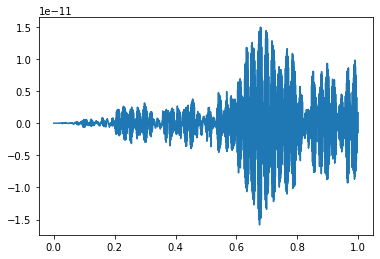

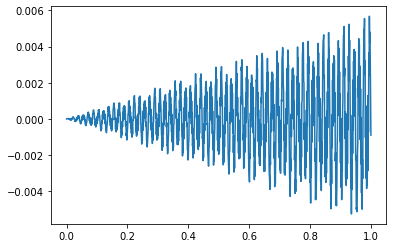

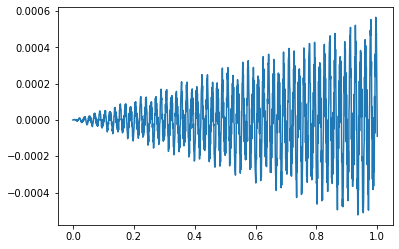

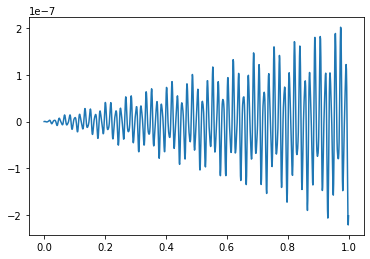

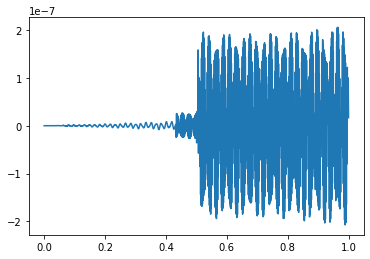

In [33]:
plt.plot(resultsDOP[1]['t'][0,:], resultsDOP[1][coord][0,:] - resultsMagnus[1][coord][0,:])
plt.show()

plt.plot(resultsDOP[1]['t'][0,:], resultsDOP[1][coord][0,:] - resultsRK45Regular[1][coord][0,:])
plt.show()

plt.plot(resultsDOP[1]['t'][0,:], resultsDOP[1][coord][0,:] - resultsRK45Regular8[1][coord][0,:])
plt.show()

plt.plot(resultsDOP[1]['t'][0,:], resultsDOP[1][coord][0,:] - resultsRK45Quat[1][coord][0,:])
plt.show()

plt.plot(resultsDOP[1]['t'][0,:], resultsDOP[1][coord][0,:] - resultsRK45Quat8[1][coord][0,:])
plt.show()

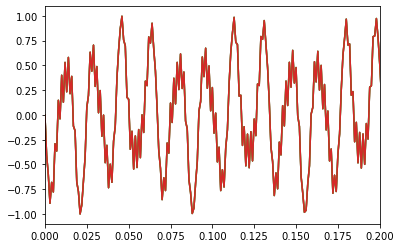

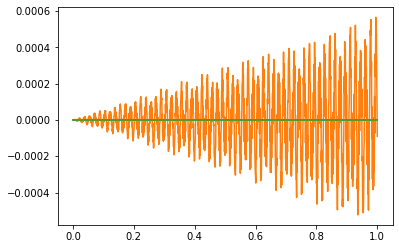

In [32]:
particle = 0
coord = 'sy'
plt.plot(resultsDOP[1]['t'][0,:], resultsDOP[1][coord][0,:])
plt.plot(resultsMagnus[1]['t'][0,:], resultsMagnus[1][coord][0,:])
plt.plot(resultsRK45Regular[1]['t'][0,:], resultsRK45Regular[1][coord][0,:])
plt.plot(resultsRK45Regular[1]['t'][0,:], resultsRK45Quat[1][coord][0,:])
plt.xlim(0, 0.2)
plt.show()

particle = 0
coord = 'sy'
plt.plot(resultsDOP[1]['t'][0,:], resultsDOP[1][coord][0,:] - resultsMagnus[1][coord][0,:])
plt.plot(resultsDOP[1]['t'][0,:], resultsDOP[1][coord][0,:] - resultsRK45Regular8[1][coord][0,:])
plt.plot(resultsDOP[1]['t'][0,:], resultsDOP[1][coord][0,:] - resultsRK45Quat8[1][coord][0,:])

In [24]:
parameters['integratorType']='1'
parameters['h']='1.0e-8'
writeParameterFile(filename, parameters)
outname = outDir + 'initTestRK45.out'
!~/Spin-tracking/cpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}
resultsRK45CPU = readInOutputFile(outname)

'''
writeParameterFile(filename, particle='neutron', V=V, T=T, gas_coll=gas_coll, diffuse=diffuse, 
                   gravity=gravity, B0=B0, E=E, numParticles=numParticles, 
                   t0=t0, tf=tf, ioutInt=ioutInt, integratorType=integratorType, 
                   a=a, w=w, keepStepSize=keepStepSize, fixedStepSize=fixedStepSize)
outname = outDir + 'initTestRK45.out'
!~/Spin-tracking/gpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}
resultsRK45GPU = readInOutputFile(outname)
'''

initializing
initialized
0, 0.01, 2745
1, 0.02, 1779
2, 0.03, 2154
3, 0.04, 2389
4, 0.05, 2389
5, 0.06, 2394
^C


"\nwriteParameterFile(filename, particle='neutron', V=V, T=T, gas_coll=gas_coll, diffuse=diffuse, \n                   gravity=gravity, B0=B0, E=E, numParticles=numParticles, \n                   t0=t0, tf=tf, ioutInt=ioutInt, integratorType=integratorType, \n                   a=a, w=w, keepStepSize=keepStepSize, fixedStepSize=fixedStepSize)\noutname = outDir + 'initTestRK45.out'\n!~/Spin-tracking/gpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}\nresultsRK45GPU = readInOutputFile(outname)\n"

In [216]:
parameters['integratorType']='2'
writeParameterFile(filename, parameters)
outname = outDir + 'initTestMagnus.out'
!~/Spin-tracking/cpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}
resultsMagnusCPU = readInOutputFile(outname)

'''
writeParameterFile(filename, particle='neutron', V=V, T=T, gas_coll=gas_coll, diffuse=diffuse, 
                   gravity=gravity, B0=B0, E=E, numParticles=numParticles, 
                   t0=t0, tf=tf, ioutInt=ioutInt, integratorType=integratorType, a=a, w=w)
outname = outDir + 'initTestMagnus.out'
!~/Spin-tracking/gpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}
resultsMagnusGPU = readInOutputFile(outname)
'''

initializing
initialized
0, 0.001, 42
1, 0.002, 31
2, 0.003, 43
3, 0.004, 43
4, 0.005, 44
5, 0.006, 37
6, 0.007, 48
7, 0.008, 43
8, 0.009, 43
9, 0.01, 43
10, 0.011, 37
11, 0.012, 42
12, 0.013, 42
13, 0.014, 36
14, 0.015, 37
15, 0.016, 37
16, 0.017, 38
17, 0.018, 37
18, 0.019, 38
19, 0.02, 37
20, 0.021, 38
21, 0.022, 38
22, 0.023, 38
23, 0.024, 38
24, 0.025, 38
25, 0.026, 38
26, 0.027, 38
27, 0.028, 38
28, 0.029, 38
29, 0.03, 38
30, 0.031, 37
31, 0.032, 38
32, 0.033, 38
33, 0.034, 38
34, 0.035, 38
35, 0.036, 38
36, 0.037, 38
37, 0.038, 38
38, 0.039, 38
39, 0.04, 38
40, 0.041, 38
41, 0.042, 38
42, 0.043, 38
43, 0.044, 38
44, 0.045, 38
45, 0.046, 38
46, 0.047, 38
47, 0.048, 38
48, 0.049, 38
49, 0.05, 38
50, 0.051, 38
51, 0.052, 38
52, 0.053, 39
53, 0.054, 39
54, 0.055, 38
55, 0.056, 38
56, 0.057, 38
57, 0.058, 38
58, 0.059, 38
59, 0.06, 38
60, 0.061, 38
61, 0.062, 38
62, 0.063, 38
63, 0.064, 38
64, 0.065, 38
65, 0.066, 37
66, 0.067, 38
67, 0.068, 38
68, 0.069, 38
69, 0.07, 38
70, 0.071, 3

556, 0.557, 32
557, 0.558, 32
558, 0.559, 32
559, 0.56, 32
560, 0.561, 32
561, 0.562, 32
562, 0.563, 32
563, 0.564, 32
564, 0.565, 32
565, 0.566, 32
566, 0.567, 32
567, 0.568, 32
568, 0.569, 32
569, 0.57, 32
570, 0.571, 32
571, 0.572, 32
572, 0.573, 32
573, 0.574, 32
574, 0.575, 32
575, 0.576, 32
576, 0.577, 32
577, 0.578, 32
578, 0.579, 32
579, 0.58, 32
580, 0.581, 32
581, 0.582, 32
582, 0.583, 32
583, 0.584, 32
584, 0.585, 32
585, 0.586, 32
586, 0.587, 32
587, 0.588, 32
588, 0.589, 32
589, 0.59, 32
590, 0.591, 32
591, 0.592, 32
592, 0.593, 32
593, 0.594, 32
594, 0.595, 32
595, 0.596, 32
596, 0.597, 32
597, 0.598, 32
598, 0.599, 32
599, 0.6, 32
600, 0.601, 32
601, 0.602, 32
602, 0.603, 32
603, 0.604, 32
604, 0.605, 32
605, 0.606, 32
606, 0.607, 32
607, 0.608, 32
608, 0.609, 32
609, 0.61, 32
610, 0.611, 32
611, 0.612, 32
612, 0.613, 32
613, 0.614, 32
614, 0.615, 32
615, 0.616, 32
616, 0.617, 32
617, 0.618, 32
618, 0.619, 32
619, 0.62, 32
620, 0.621, 32
621, 0.622, 32
622, 0.623, 32
623

"\nwriteParameterFile(filename, particle='neutron', V=V, T=T, gas_coll=gas_coll, diffuse=diffuse, \n                   gravity=gravity, B0=B0, E=E, numParticles=numParticles, \n                   t0=t0, tf=tf, ioutInt=ioutInt, integratorType=integratorType, a=a, w=w)\noutname = outDir + 'initTestMagnus.out'\n!~/Spin-tracking/gpuTestmain ~/Spin-tracking/scripts/neutronTest.txt {outname}\nresultsMagnusGPU = readInOutputFile(outname)\n"

In [223]:
for name in resultsDOPCPU[1].dtype.names:
    a = resultsDOPCPU[1][name]
    b = resultsRK45CPU[1][name]
    print(name, np.allclose(a, b))

t True
xx True
xy True
xz True
vx True
vy True
vz True
sx False
sy False
sz False


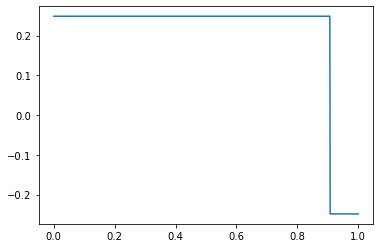

In [235]:
plt.plot(resultsDOPCPU[1]['t'][0], resultsDOPCPU[1]['vz'].mean(axis=0))

DOP: CPU and GPU Agree

RK45: CPU and GPU all agree with the original DOP CPU results

Magnus: neither CPU nor GPU agree with DOP
    CPU and GPU don't agree either
    Appears to be the NaN issue causing this
        When I mask NaN values this disappears, but they don't share the same NaN locations which is strange
    When masking NaN values it also agrees with the other methods, but we shouldn't be seeing NaN to begin with